In [11]:
import pandas as pd
import json

# Load JSON file
with open('classification_results_20260309_112912.json', 'r', encoding="utf-8") as f:
    data = json.load(f)

# Convert to pandas DataFrame
df = pd.DataFrame(data)

# Classify by 'classification' and get top 5 items
top_5 = df.groupby('classification').head(5)

# Display head and summary
# print("Head of top 5 items per classification:")
# print(top_5[['head', 'summary']])

pd.set_option('display.max_colwidth', None)
top_5[['classification', 'summary']]

,classification,summary
0,Politics,"José Antonio Kast has won the Chilean presidential election with 58% of the votes, defeating his left-wing opponent Jeannette Jara with 42%. Kast's campaign focused on security and migration, and he presented himself as a moderate conservative, avoiding radical statements that led to his defeat in the 2021 election. As president, Kast is expected to rely on pragmatic policies, deregulation, and tax cuts to stimulate the economy, but his ideological stance as an erzkatholischer Konservativer may limit his ability to implement a comprehensive right-wing agenda."
1,Integration,"According to the 2024 report from the Swiss State Secretariat for Economic Affairs, approximately 53,700 people immigrated to Switzerland last year, a decrease of 10,000 from the previous year, but the country remains an attractive destination for migrants, with a high rate of integration into the workforce."
2,Economy,"The Swiss government has released a report predicting a population growth of 15% over the next 30 years, driven mainly by immigration, which is expected to reach 10.5 million by 2050. The report highlights the positive effects of immigration, including mitigating the impact of aging on the economy and filling the birth rate gap, but also acknowledges the challenges of accommodating a growing population, such as increased demand for resources and infrastructure."
3,Economy,"Nidwalden, a canton in central Switzerland, has undergone significant economic and demographic changes due to its improved transportation infrastructure, particularly the construction of the Gotthard highway and the Seelisbergtunnel, which connected it to major cities and facilitated the growth of industries such as aviation. As a result, Nidwalden has transformed from a poor agricultural region to a financially strong canton with a growing population, becoming a preferred residence for wealthy individuals and a major employer in the region."
4,Economy,"Nidwalden, a canton in central Switzerland, has undergone significant economic and demographic changes since its isolation was alleviated by the construction of roads and highways. The canton's accessibility has brought prosperity, but also increased traffic, transforming it into a transit region. The development of the Gotthard route and the construction of notable infrastructure projects, such as the Lehnenviadukt and the Seelisbergtunnel, have contributed to the canton's growth, with the population increasing from approximately 28,600 in 1980 to 43,500 in 2020."
5,Economy,"UBS, a Swiss bank, reported solid half-year earnings despite market turbulence, but its stock price is limited by uncertainty over its future capital requirements. The bank's CEO, Sergio Ermotti, criticized the Swiss government's proposed regulations as ""unreasonable"" and ""extreme,"" which could require the bank to raise an additional $42 billion in capital."
6,Politics,"Kilmar García, a 29-year-old Salvadoran migrant, was deported to El Salvador by the Trump administration without a court hearing, sparking protests and solidarity from Democrats and left-wing organizations in the US."
7,Politics,"Over 100,000 people attended a massive memorial service in Arizona for Charlie Kirk, a 31-year-old right-wing activist who was murdered in Utah, with the event turning into a powerful manifestation of the MAGA movement and its supporters, including President Donald Trump."
8,Politics,"The document contains four letters to the editor in a Swiss newspaper, discussing various topics. The letters cover issues such as the COVID-19 pandemic, animal welfare, demographic trends, and the Swiss airline industry. The writers express their opinions on how the government and society should address these issues, with some calling for reflection and improvement, while others advocate for specific policies and actions."
9,Politics,"Christophe Darbellay, a prominent Swiss politician, is emphasizing the importance of preserving the countr

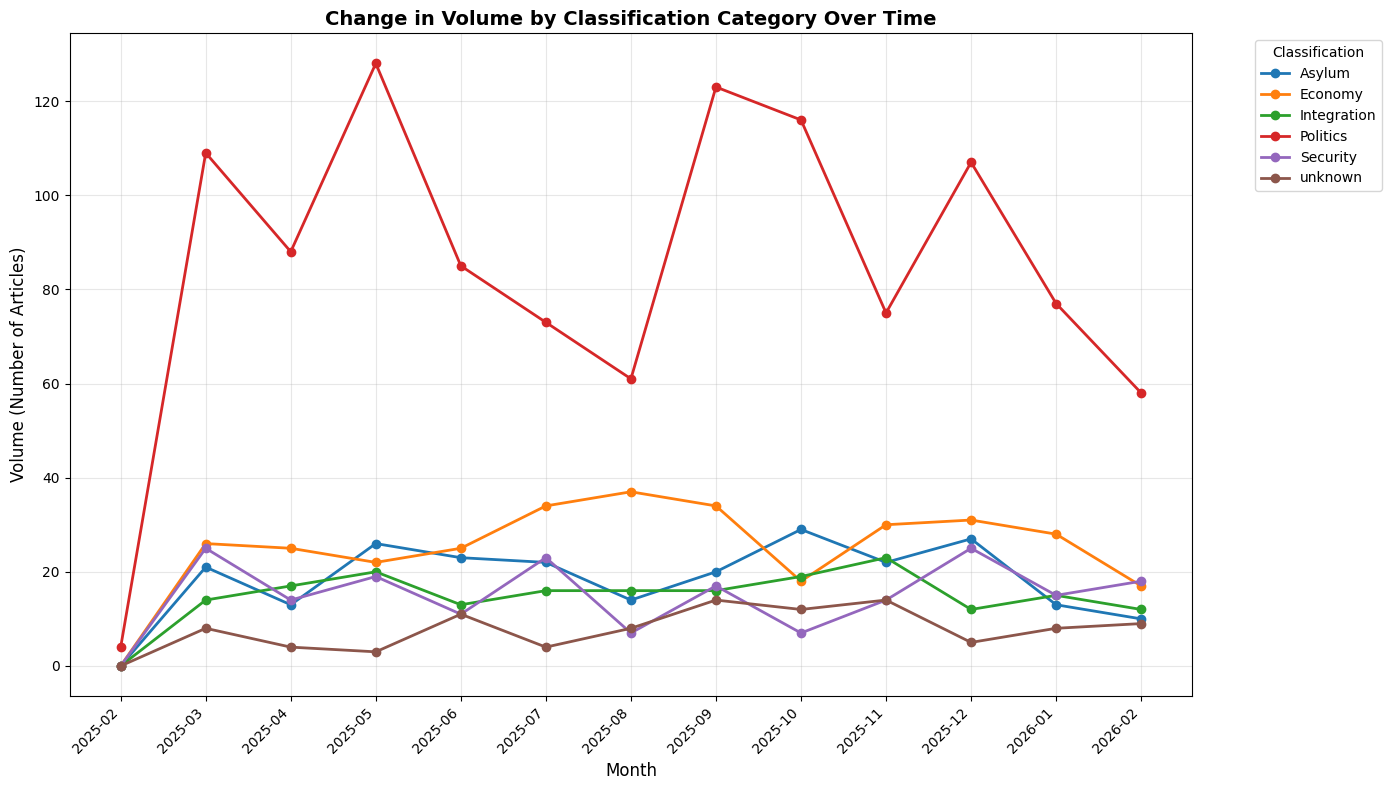

In [12]:
## Volume Change by Classification Category Over Time

"""This analysis visualizes the temporal trends in article volume across different classification categories, showing how media coverage patterns have evolved month by month.

"""
# visualize in line graphs the change in volumn by the classification category over time (by month) Use matplotlib for visualization.
import matplotlib.pyplot as plt
import pandas as pd
from datetime import datetime

def visualize_volume_over_time(results):
    # Convert pubtime to datetime
    df_temp = pd.DataFrame(results)
    df_temp['pubtime'] = pd.to_datetime(df_temp['pubtime'])
    df_temp['year_month'] = df_temp['pubtime'].dt.to_period('M')
    
    # Group by classification and month
    volume_by_month = df_temp.groupby(['year_month', 'classification']).size().unstack(fill_value=0)
    
    # Plot
    plt.figure(figsize=(14, 8))
    for column in volume_by_month.columns:
        plt.plot(volume_by_month.index.astype(str), volume_by_month[column], marker='o', label=column, linewidth=2)
    
    plt.xlabel('Month', fontsize=12)
    plt.ylabel('Volume (Number of Articles)', fontsize=12)
    plt.title('Change in Volume by Classification Category Over Time', fontsize=14, fontweight='bold')
    plt.legend(title='Classification', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.xticks(rotation=45, ha='right')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Call the function with the data
visualize_volume_over_time(data)